In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

_here = Path(os.path.abspath(""))
while not (_here / "pixi.toml").exists():
    _here = _here.parent
    if _here == _here.parent:
        raise RuntimeError("Could not find repo root")
os.chdir(_here)

In [3]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiments_analysis.sensitivity_analysis_pipeline import (
    make_config,
    run_sensitivity_analysis_multi_seed,
)

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [4]:
BASELINES_PATH = "experiments/benchmark_output_files/sensitivity_analysis/hln_baselines.yaml"
RUNS_PATH = "experiments/benchmark_output_files/sensitivity_analysis/hln_merge.yaml"
cfg = make_config(BASELINES_PATH, RUNS_PATH)
output_dir = cfg["output_dir"]
figures_output_dir = Path(cfg["figures_output_dir"])
figures_output_dir.mkdir(exist_ok=True, parents=True)
Path(output_dir).mkdir(parents=True, exist_ok=True)

In [5]:
run_sensitivity_analysis_multi_seed(cfg)

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:243: UserWarning: NaN inf in the following destriped data: ['collapse_label', 'seed_42__p_merge_50', 'seed_42__p_merge_80', 'seed_42__p_merge_100', 'seed_64__p_merge_50', 'seed_64__p_merge_80', 'seed_64__p_merge_100', 'seed_754__p_merge_80', 'seed_754__p_merge_100']
  warn(f"NaN inf in the following destriped data: {list_nan}")


,name,converged
0,seed_42__p_merge_0.01,True
1,seed_42__p_merge_10,True
2,seed_42__p_merge_25,True
3,seed_42__p_merge_50,True
4,seed_42__p_merge_80,True
5,seed_42__p_merge_100,True
6,seed_64__p_merge_0.01,True
7,seed_64__p_merge_10,True
8,seed_64__p_merge_25,True
9,seed_64__p_merge_50,True


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)


2SN 0
b2c-sym-c_mean 1
bin_level_normalization 2
collapse_label 3
dividing_99_quantile 4
original 5
ours 6
seed_42__p_merge_0.01 7
seed_42__p_merge_10 8
seed_42__p_merge_100 9
seed_42__p_merge_25 10
seed_42__p_merge_50 11
seed_42__p_merge_80 12
seed_64__p_merge_0.01 13
seed_64__p_merge_10 14
seed_64__p_merge_100 15
seed_64__p_merge_25 16
seed_64__p_merge_50 17
seed_64__p_merge_80 18
seed_754__p_merge_0.01 19
seed_754__p_merge_10 20
seed_754__p_merge_100 21
seed_754__p_merge_25 22
seed_754__p_merge_50 23
seed_754__p_merge_80 24


In [ ]:
output_dir

'results/segmentation_sensitivity/human_lymph_node/analysis_merge'

## Global structure analysis plots

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:873: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/sensitivity_analysis_pipeline.py:886: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


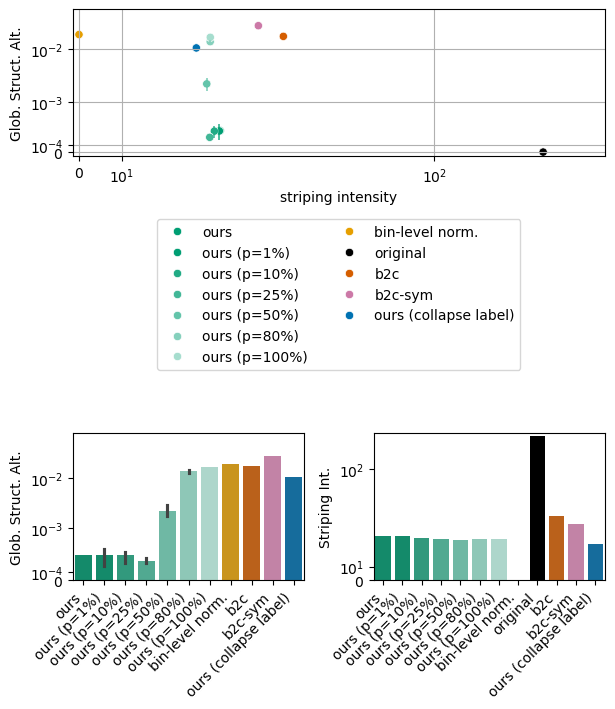

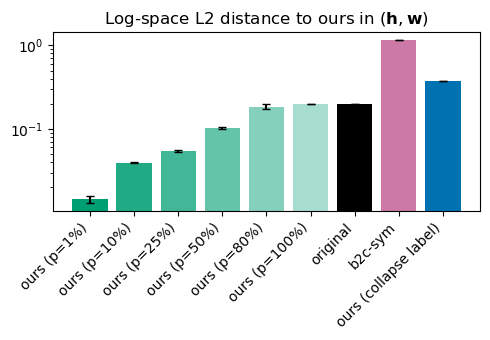

In [21]:
from src.experiments_analysis.sensitivity_analysis_pipeline import real_data_plots

real_data_plots(output_dir, figures_output_dir, "merge")

## Qualitative analysis

overall striping intensity


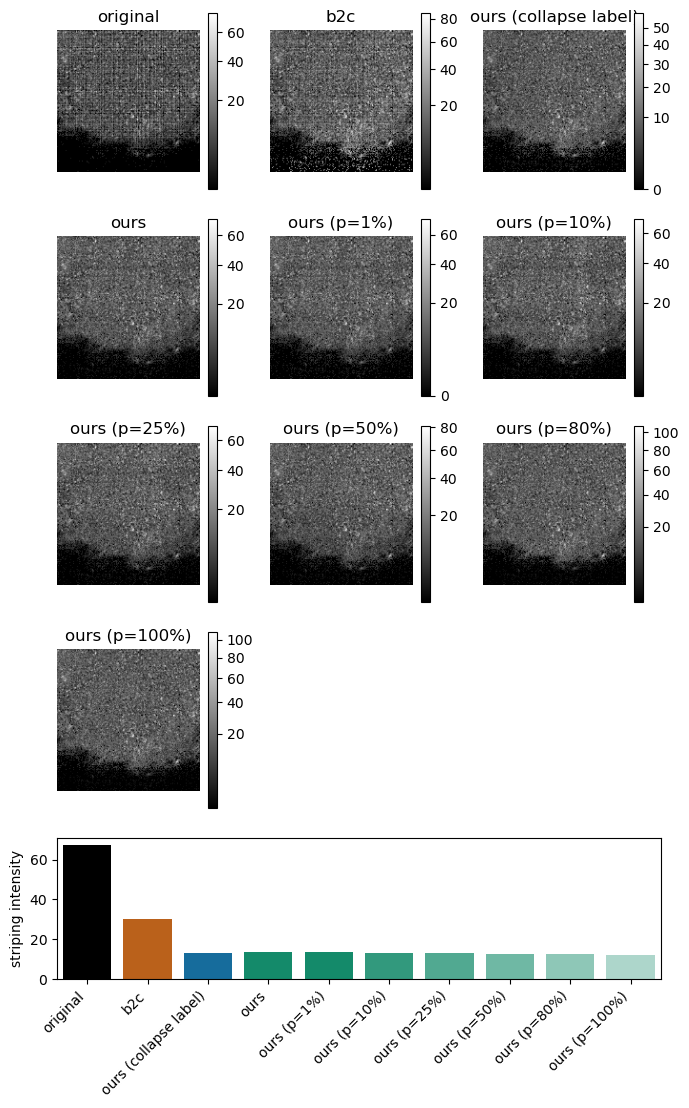

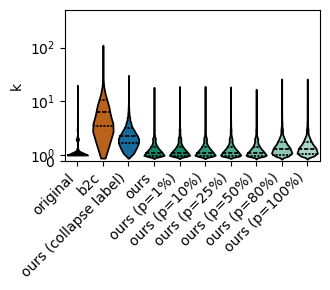

In [24]:
from src.experiments_analysis.sensitivity_analysis_pipeline import (
    qualitative_plots_human_lymph_node,
)

qualitative_plots_human_lymph_node(output_dir, figures_output_dir, "merge")

<Figure size 700.9x560.72 with 0 Axes>

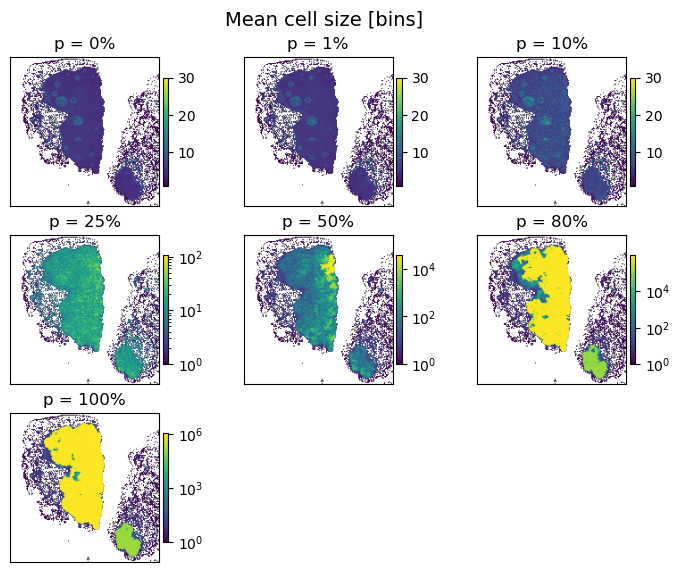

In [23]:
from src.experiments_analysis.sensitivity_analysis_pipeline import load_cell_size_inputs
from src.experiments_analysis.plots_cell_size import plot_mean_cell_size

# load_cell_size_inputs expects a single-seed config with a flat "runs" key.
# Use seed 42's runs for the cell-size visualization.
cfg_42_compat = {
    "runs": cfg["seeds"][42]["runs"],
}
labels_by_p, coords, stats_df = load_cell_size_inputs(cfg_42_compat)
plot_mean_cell_size(labels_by_p, coords, stats_df, bin_size=20)
plt.savefig(figures_output_dir / "avg_cell_size.pdf")

plt.show()

<string>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


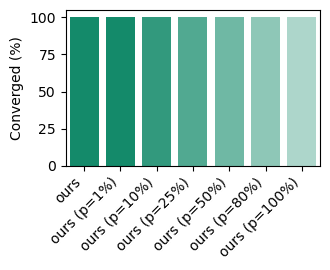

In [15]:
from src.experiments_analysis.sensitivity_analysis_pipeline import convergence_barplot

ax = convergence_barplot(output_dir, experiment_type="merge")
plt.show()